<a href="https://colab.research.google.com/github/paulaadel5/Video-Action-Recognition/blob/main/DL5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python-headless tensorflow numpy -q
!pip install einops -q
!pip install transformers accelerate -q
print("Done")


Done


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# IMPORT LIBRARIE
import cv2
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import WeightedRandomSampler
from collections import Counter
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import (
    compute_class_weight
)


In [ ]:

# ════════════════════════════════════════════════
# DEVICE
# ════════════════════════════════════════════════

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)




Device: cuda


In [ ]:
# DATASET PATH: sequences folder
DATASET_PATH = "/content/drive/MyDrive/processed_data/sequences"



In [ ]:
# PARAMETERS
NUM_CLASSES = 2
BATCH_SIZE = 2
EPOCHS = 50
LEARNING_RATE = 5e-5
classes = ["cheating", "normal"]
label_map = {
    "cheating": 0,
    "normal": 1
}

In [ ]:
# AUGMENTATION FUNCTIONS[block overfitting
def augment_sequence(sequence):
    # Horizontal Flip
    if random.random() < 0.5:

        sequence = np.flip(
            sequence,
            axis=2
        ).copy()

    # Brightness
#increase تنوع data
    if random.random() < 0.3:

        factor = random.uniform(0.8, 1.2)

        sequence = np.clip(
            sequence * factor,
            0,
            255
        )

    return sequence

In [ ]:
# CUSTOM DATASET
#read video
class VideoDataset(Dataset):

    def __init__(self, split, augment=False):
        self.samples = []  #store pass+ label

        self.augment = augment
        #folder
        split_path = os.path.join(
            DATASET_PATH,
            split
        )

        for class_name in classes:
            class_path = os.path.join(
                split_path,
                class_name
            )
            #read all file , store in list
            for file in os.listdir(class_path):

                if file.endswith(".npy"):

                    file_path = os.path.join(
                        class_path,
                        file
                    )

                    self.samples.append(
                        (
                            file_path,
                            label_map[class_name]
                        )
                    )
    #retern num samples
    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        file_path, label = self.samples[idx]

        # LOAD SEQUENCE[video]
        sequence = np.load(file_path)

        # AUGMENTATION
        if self.augment:

            sequence = augment_sequence(
                sequence
            )
        # NORMALIZATION
        sequence = sequence / 255.0

        # TO TENSOr
        sequence = torch.tensor(
            sequence,
            dtype=torch.float32
        )

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return sequence, label


In [ ]:
# LOAD TRAIN DATA
X_train = []
y_train = []

train_path = os.path.join(DATASET_PATH, "train")
for class_name in classes:
    class_path = os.path.join(train_path, class_name)

    for file in os.listdir(class_path):

        if file.endswith(".npy"):
            file_path = os.path.join(class_path, file)
            sequence = np.load(file_path)
            X_train.append(sequence)
            y_train.append(label_map[class_name])
            print("Loaded Train:", file_path)

Loaded Train: /content/drive/MyDrive/processed_data/sequences/train/cheating/6672299 - Trim2_s016.npy
Loaded Train: /content/drive/MyDrive/processed_data/sequences/train/cheating/6672299 - Trim2_s024.npy
Loaded Train: /content/drive/MyDrive/processed_data/sequences/train/cheating/6672299 - Trim2_s008.npy
Loaded Train: /content/drive/MyDrive/processed_data/sequences/train/cheating/6672299 - Trim2_s032.npy
Loaded Train: /content/drive/MyDrive/processed_data/sequences/train/cheating/6672299 - Trim2_s000.npy
Loaded Train: /content/drive/MyDrive/processed_data/sequences/train/cheating/6672299 - Trim2_s040.npy
Loaded Train: /content/drive/MyDrive/processed_data/sequences/train/cheating/7092086_s056.npy
Loaded Train: /content/drive/MyDrive/processed_data/sequences/train/cheating/7092086_s040.npy
Loaded Train: /content/drive/MyDrive/processed_data/sequences/train/cheating/7092086_s008.npy
Loaded Train: /content/drive/MyDrive/processed_data/sequences/train/cheating/7092086_s000.npy
Loaded Train

In [ ]:
# CREATE DATASETS
#[divid data]
train_dataset = VideoDataset(
    "train",
    augment=True
)

val_dataset = VideoDataset(
    "val",
    augment=False
)

test_dataset = VideoDataset(
    "test",
    augment=False
)



In [ ]:
train_labels = [
    label
    for _, label in train_dataset.samples
]

In [ ]:
# Balance[weight class]
weights = 1. / torch.tensor([419, 102], dtype=torch.float32)

sample_weights = [
    weights[label]
    for label in train_labels
]

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [ ]:
# DATALOADERS
#[balancing with training batch]
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
#CHECK BALANCE
sampled_labels = []

for _, labels in train_loader:
    sampled_labels.extend(labels.numpy())

print(Counter(sampled_labels))

Counter({np.int64(0): 275, np.int64(1): 246})


In [ ]:
#CHECK BALANCE
counts = Counter(sampled_labels)

ratio = max(counts.values()) / min(counts.values())
print(ratio)

1.1178861788617886


In [ ]:
# BUILD TIMESFORMER MODEL
class SimpleTimeSformer(nn.Module):
    def __init__(
        self,
        num_classes=2,
        embed_dim=256,
        num_heads=8
    ):

        super(SimpleTimeSformer, self).__init__()

        # PATCH EMBEDDING DIVIDED IMAGE TO PATCH
        self.patch_embed = nn.Conv2d(
            in_channels=3,
            out_channels=embed_dim,
            kernel_size=16,
            stride=16
        )

        # SPATIAL ATTENTION [INTRA] IN FRAME
        self.spatial_attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            batch_first=True
        )

        # TEMPORAL ATTENTION [INTER] BEDTWEEN FRAMES
        self.temporal_attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            batch_first=True
        )

        # NORMALIZATION[0 to 1]
        self.norm = nn.LayerNorm(embed_dim)


        # CLASSIFIER :classifier (cheat or normal)
        self.fc = nn.Linear(
            embed_dim,
            num_classes
        )

    def forward(self, x):
        B, T, H, W, C = x.shape

        all_features = []

        # PROCESS EACH FRAME
        for t in range(T):

            frame = x[:, t]

            # (B,H,W,C) → (B,C,H,W)

            frame = frame.permute(
                0, 3, 1, 2
            )

            # PATCH EMBEDDING

            patches = self.patch_embed(frame)

            # flatten patches[become sequqnce]

            patches = patches.flatten(2)
            patches = patches.transpose(1, 2)


            # SPATIAL ATTENTION
            spatial_out, _ = self.spatial_attention(
                patches,
                patches,
                patches
            )

            spatial_out = self.norm(
                spatial_out
            )

            # average all patches

            frame_feature = spatial_out.mean(dim=1)

            all_features.append(frame_feature)

        # STACK TEMPORAL FEATURE
        #collect frames
        temporal_input = torch.stack(
            all_features,
            dim=1
        )

        # TEMPORAL ATTENTION


        temporal_out, _ = self.temporal_attention(
            temporal_input,
            temporal_input,
            temporal_input
        )

        temporal_out = self.norm(
            temporal_out
        )

        # GLOBAL FEATURE

        final_feature = temporal_out.mean(dim=1)

        # CLASSIFICATION
        output = self.fc(final_feature)

        return output


model = SimpleTimeSformer(
    num_classes=NUM_CLASSES
).to(device)

print(model)



SimpleTimeSformer(
  (patch_embed): Conv2d(3, 256, kernel_size=(16, 16), stride=(16, 16))
  (spatial_attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
  )
  (temporal_attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)


In [ ]:
# LOSS FUNCTION[multiC]
criterion = nn.CrossEntropyLoss()
# OPTIMIZER (ADAMW)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)


In [ ]:
# EARLY STOPPING VARIABLES
best_val_loss = float('inf')
patience = 3
counter = 0

for epoch in range(EPOCHS):

    # TRAINING
    model.train()

    train_loss = 0
    correct = 0
    total = 0

    for videos, labels in train_loader:

        videos = videos.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(videos)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    avg_train_loss = train_loss / len(train_loader)

    # VALIDATION
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for videos, labels in val_loader:

            videos = videos.to(device)
            labels = labels.to(device)

            outputs = model(videos)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    avg_val_loss = val_loss / len(val_loader)

    # PRINT METRICS
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {avg_val_loss:.4f}")
    print(f"Val Acc: {val_acc:.2f}%")

    # EARLY STOPPING
    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss
        counter = 0

        torch.save(model.state_dict(), "best_model.pth")
        print(" Best model saved")

    else:

        counter += 1
        print(f" Early stopping counter: {counter}/{patience}")

        if counter >= patience:
            print(" Early stopping triggered")
            break


Epoch [1/50]
Train Loss: 0.7382
Train Acc: 50.10%
Val Loss: 0.7509
Val Acc: 24.30%
 Best model saved

Epoch [2/50]
Train Loss: 0.6487
Train Acc: 59.88%
Val Loss: 0.5012
Val Acc: 75.70%
 Best model saved

Epoch [3/50]
Train Loss: 0.4808
Train Acc: 76.78%
Val Loss: 0.6980
Val Acc: 62.62%
 Early stopping counter: 1/3

Epoch [4/50]
Train Loss: 0.4451
Train Acc: 78.50%
Val Loss: 0.4030
Val Acc: 75.70%
 Best model saved

Epoch [5/50]
Train Loss: 0.4748
Train Acc: 76.58%
Val Loss: 0.6891
Val Acc: 61.68%
 Early stopping counter: 1/3

Epoch [6/50]
Train Loss: 0.4538
Train Acc: 80.23%
Val Loss: 0.5272
Val Acc: 76.64%
 Early stopping counter: 2/3

Epoch [7/50]
Train Loss: 0.4461
Train Acc: 78.89%
Val Loss: 0.5597
Val Acc: 73.83%
 Early stopping counter: 3/3
 Early stopping triggered


In [ ]:
# TESTING
model.eval()

test_preds = []
test_labels = []

with torch.no_grad():

    for videos, labels in test_loader:
        videos = videos.to(device)
        labels = labels.to(device)
        outputs = model(videos)

        _, predicted = torch.max(
            outputs,
            1
        )

        # ALERT SYSTEM

        frame_counter = 0

fps = 30

for videos, labels in test_loader:

    videos = videos.to(device)

    labels = labels.to(device)

    outputs = model(videos)

    _, predicted = torch.max(outputs, 1)

    # LOOP OVER BATCH

    for i, pred in enumerate(predicted):

        # CHEATING DETECTED

        if pred.item() == 0:

            # TIMESTAMP
            timestamp = frame_counter / fps

            print(
                f" Cheating Detected "
                f"at {timestamp:.2f} sec"
            )

            # GET FRAME SNAPSHOT
            frame = videos[i][0].cpu().numpy()


            # BACK TO IMAGE FORMAT
            frame = (frame * 255).astype(np.uint8)


            # SAVE IMAGE
            cv2.imwrite(

                f"cheating_{frame_counter}.jpg",

                frame
            )

            print(
                " Snapshot Saved"
            )

        else:

            print(
                " Normal Behavior"
            )

        frame_counter += 1

        # SAVE RESULTS

        test_preds.extend(
            predicted.cpu().numpy()
        )

        test_labels.extend(
            labels.cpu().numpy()
        )

 Cheating Detected at 0.00 sec
 Snapshot Saved
 Cheating Detected at 0.03 sec
 Snapshot Saved
 Cheating Detected at 0.07 sec
 Snapshot Saved
 Cheating Detected at 0.10 sec
 Snapshot Saved
 Cheating Detected at 0.13 sec
 Snapshot Saved
 Cheating Detected at 0.17 sec
 Snapshot Saved
 Cheating Detected at 0.20 sec
 Snapshot Saved
 Cheating Detected at 0.23 sec
 Snapshot Saved
 Cheating Detected at 0.27 sec
 Snapshot Saved
 Cheating Detected at 0.30 sec
 Snapshot Saved
 Cheating Detected at 0.33 sec
 Snapshot Saved
 Cheating Detected at 0.37 sec
 Snapshot Saved
 Cheating Detected at 0.40 sec
 Snapshot Saved
 Cheating Detected at 0.43 sec
 Snapshot Saved
 Cheating Detected at 0.47 sec
 Snapshot Saved
 Cheating Detected at 0.50 sec
 Snapshot Saved
 Cheating Detected at 0.53 sec
 Snapshot Saved
 Cheating Detected at 0.57 sec
 Snapshot Saved
 Cheating Detected at 0.60 sec
 Snapshot Saved
 Cheating Detected at 0.63 sec
 Snapshot Saved
 Cheating Detected at 0.67 sec
 Snapshot Saved
 Cheating Det

In [ ]:
# TEST ACCURACY
test_acc = accuracy_score(
    test_labels,
    test_preds
)
print(
    "\nTest Accuracy:",
    test_acc
)


Test Accuracy: 0.85


In [ ]:
# CLASSIFICATION REPORT
print(
    classification_report(
        test_labels,
        test_preds,
        target_names=classes
    )
)

              precision    recall  f1-score   support

    cheating       1.00      0.81      0.89       188
      normal       0.59      1.00      0.74        52

    accuracy                           0.85       240
   macro avg       0.80      0.90      0.82       240
weighted avg       0.91      0.85      0.86       240



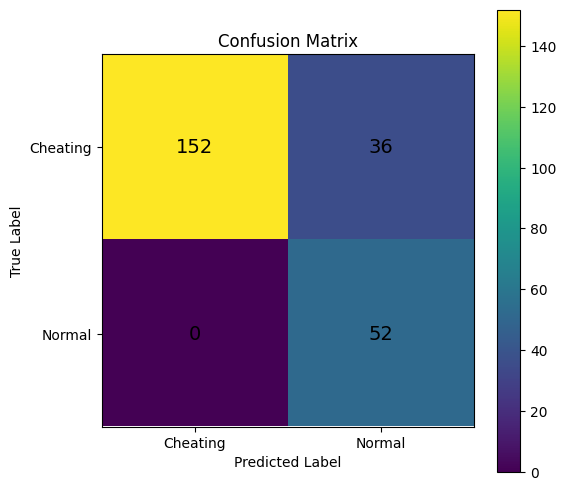

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(
    test_labels,
    test_preds
)

# =========================
# PLOT
# =========================

plt.figure(figsize=(6,6))

plt.imshow(cm)

# labels
classes = ["Cheating", "Normal"]

plt.xticks(
    np.arange(len(classes)),
    classes
)

plt.yticks(
    np.arange(len(classes)),
    classes
)

# title
plt.title("Confusion Matrix")

# axis labels
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# numbers inside boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=14
        )

# color bar
plt.colorbar()

plt.show()

In [ ]:
# SAVE FINAL MODEL
torch.save(
    model.state_dict(),
    "timesformer_model_final.pth"
)
print(
    "Final Model Saved Successfully"
)

Final Model Saved Successfully
